## Data Loading and Aggregation

This section focuses on loading the time series data and aggregating it to a daily level for analysis. Time series analysis often begins with preparing the raw data into a format suitable for modeling, which may involve cleaning, transforming, and aggregating the data.

In [1]:
from prophet import Prophet
from prophet.plot import plot_yearly
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.make_holidays import make_holidays_df

In [2]:
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the CSV file in Google Drive
file_path = '/content/drive/MyDrive/Data Science Lecture Notes/data/store_sales_time_series/train.csv'

sales_df = pd.read_csv(file_path)
agg_sales_df = sales_df['sales'].groupby(sales_df['date']).sum()
agg_sales_df = pd.DataFrame(agg_sales_df)
agg_sales_df['time_step'] = range(len(agg_sales_df))
agg_sales_df.dropna(inplace=True)

Mounted at /content/drive


## Time Series Forecasting with Prophet

Prophet is a time series forecasting library developed by Facebook. It is designed to handle time series data with strong seasonality and holiday effects. This section demonstrates how to use Prophet to model and forecast the sales data.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpoc0sl6ns/gdo0st6_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpoc0sl6ns/321l97ka.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19888', 'data', 'file=/tmp/tmpoc0sl6ns/gdo0st6_.json', 'init=/tmp/tmpoc0sl6ns/321l97ka.json', 'output', 'file=/tmp/tmpoc0sl6ns/prophet_modeln5_jrll_/prophet_model-20250808022954.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:29:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:29:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
0,2013-01-01,-297222.035247,-426126.541581,-176528.863261
1,2013-01-02,442488.272586,319185.217500,568352.416750
2,2013-01-03,342192.626387,210992.543763,469126.103972
3,2013-01-04,402471.321204,284315.412917,531059.687674
4,2013-01-05,577699.567201,455578.436267,698346.107749


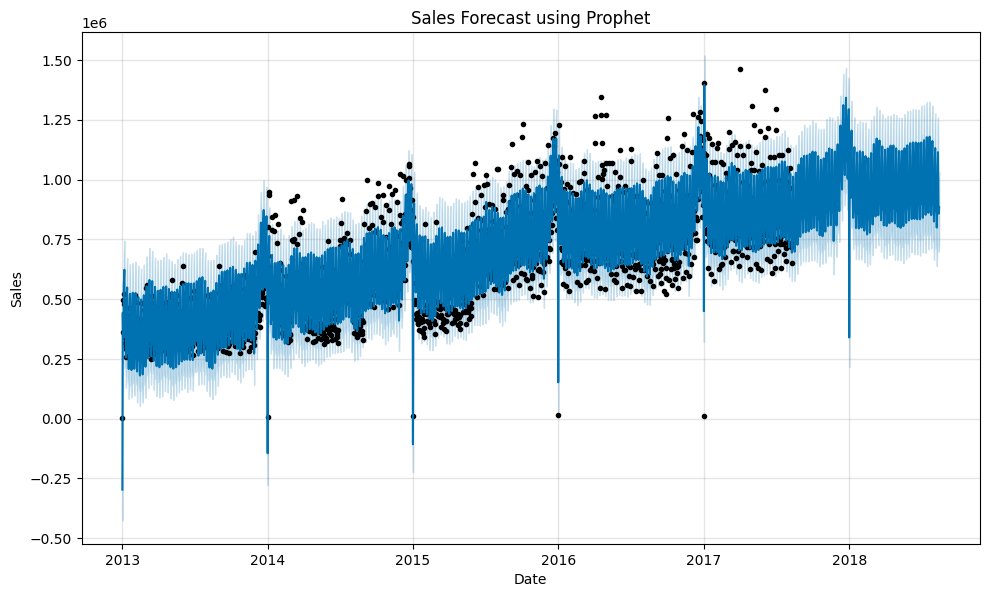

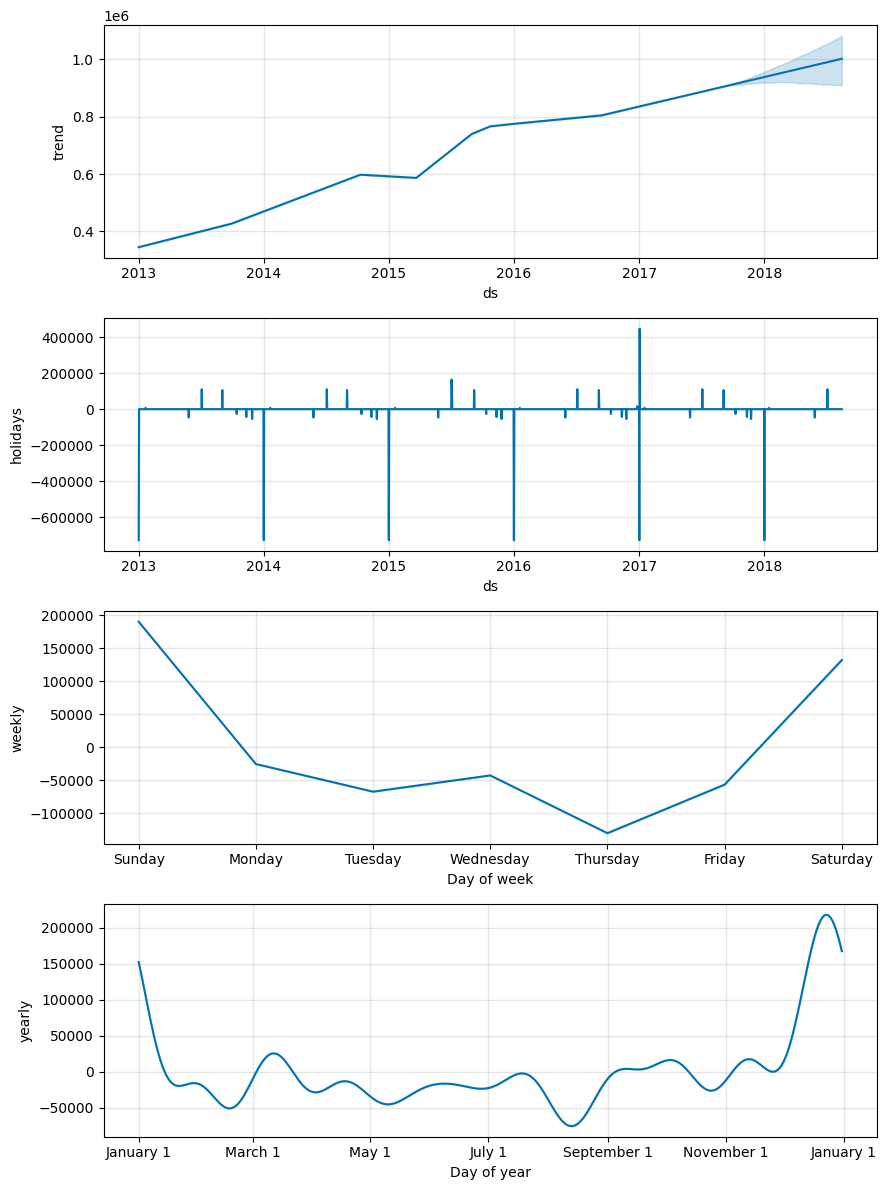

In [3]:
from prophet import Prophet

# Prepare data for Prophet (Prophet requires columns named 'ds' and 'y')
prophet_df = agg_sales_df.reset_index()
prophet_df = prophet_df[['date', 'sales']]
prophet_df.columns = ['ds', 'y']

# Initialize and fit the Prophet model
model = Prophet()
model.add_country_holidays(country_name='US')
model.fit(prophet_df)

# Create a dataframe with future dates for prediction
future = model.make_future_dataframe(periods=365) # Predict for the next year

# Make predictions
forecast = model.predict(future)

# Display the forecast dataframe
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

# Plot the forecast
fig1 = model.plot(forecast)
plt.title('Sales Forecast using Prophet')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

# Plot the components of the forecast
fig2 = model.plot_components(forecast)
plt.show()

In [5]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'Christmas Day', 'Christmas Day_lower', 'Christmas Day_upper',
       'Christmas Day (observed)', 'Christmas Day (observed)_lower',
       'Christmas Day (observed)_upper', 'Columbus Day', 'Columbus Day_lower',
       'Columbus Day_upper', 'Independence Day', 'Independence Day_lower',
       'Independence Day_upper', 'Independence Day (observed)',
       'Independence Day (observed)_lower',
       'Independence Day (observed)_upper', 'Labor Day', 'Labor Day_lower',
       'Labor Day_upper', 'Martin Luther King Jr. Day',
       'Martin Luther King Jr. Day_lower', 'Martin Luther King Jr. Day_upper',
       'Memorial Day', 'Memorial Day_lower', 'Memorial Day_upper',
       'New Year's Day', 'New Year's Day_lower', 'New Year's Day_upper',
       'New Year's Day (observed)', 'New Year's Day (observed)_lower',
       'New Year's Day (observed)_upper', 'Thanksgiving Day',
       'Thanksgiving Day_lower', 'T

In [15]:
forecast[1450:1455]

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Christmas Day (observed),...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1450,2016-12-24,832693.820817,1.056517e+06,1.310184e+06,832693.820817,832693.820817,0.0,0.0,0.0,0.000000,...,131911.413274,131911.413274,131911.413274,216579.712015,216579.712015,216579.712015,0.0,0.0,0.0,1.181185e+06
1451,2016-12-26,833255.404938,9.032831e+05,1.164683e+06,833255.404938,833255.404938,0.0,0.0,0.0,16607.612366,...,-25400.481579,-25400.481579,-25400.481579,208935.720544,208935.720544,208935.720544,0.0,0.0,0.0,1.033398e+06
1452,2016-12-27,833536.196998,8.462192e+05,1.102420e+06,833536.196998,833536.196998,0.0,0.0,0.0,0.000000,...,-67218.645711,-67218.645711,-67218.645711,202695.928593,202695.928593,202695.928593,0.0,0.0,0.0,9.690135e+05
1453,2016-12-28,833816.989059,8.605714e+05,1.107948e+06,833816.989059,833816.989059,0.0,0.0,0.0,0.000000,...,-42651.363425,-42651.363425,-42651.363425,194975.257074,194975.257074,194975.257074,0.0,0.0,0.0,9.861409e+05
1454,2016-12-29,834097.781119,7.561556e+05,1.011492e+06,834097.781119,834097.781119,0.0,0.0,0.0,0.000000,...,-130006.978091,-130006.978091,-130006.978091,185903.556499,185903.556499,185903.556499,0.0,0.0,0.0,8.899944e+05


### Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Convert 'ds' column to datetime objects
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
forecast['ds'] = pd.to_datetime(forecast['ds'])


# Merge actual sales data with Prophet forecast
prophet_results = prophet_df.merge(forecast[['ds', 'yhat']], on='ds', how='inner')

# Calculate RMSE for Prophet
rmse_prophet = np.sqrt(mean_squared_error(prophet_results['y'], prophet_results['yhat']))

# Print the RMSE
print(f'Prophet RMSE: {rmse_prophet}')

Prophet RMSE: 108182.76910211917


## Time Series Forecasting with RNNs

---



### a.Data Preparation for Time Series Models

Recurrent Neural Networks (RNNs), such as LSTMs and SimpleRNNs, require time series data to be prepared in a specific format for training. This typically involves scaling the data and creating sequences of past observations to predict future values.



Preparing time series data for machine learning models often involves several steps. For recurrent neural networks like LSTMs and RNNs, it's common to:

1.  **Scale the data:** Time series data can have varying scales, which can affect the performance of gradient-based optimization algorithms. Scaling the data to a specific range (e.g., 0 to 1) helps to normalize the input and can lead to faster and more stable training.
2.  **Create sequences:** Recurrent neural networks process data sequentially. To train them for time series forecasting, the data needs to be structured into sequences, where each input sequence corresponds to a past time window (look-back period), and the output is the value at the next time step. This process transforms the time series data into a supervised learning problem.

### b.Building Recurrent Neural Network Models

Recurrent Neural Networks (RNNs), including LSTMs (Long Short-Term Memory) and SimpleRNNs, are well-suited for sequential data like time series.

*   **LSTM Layers:** LSTMs are designed to capture long-term dependencies in sequences, making them effective for time series where past values significantly influence future values.
*   **SimpleRNN Layers:** SimpleRNNs are a basic type of recurrent network that can capture temporal dependencies, although they may struggle with very long sequences.
*   **Dense Layers:** A final Dense layer is typically used to produce the desired output, which in this case is a single predicted value for the next time step.

When building these models using the Keras Sequential API, you stack layers one after another. The `input_shape` in the first layer specifies the format of the input sequences, which is typically (number of time steps in each sequence, number of features).

### c.Training Time Series Forecasting Models

Training a neural network for time series forecasting involves feeding the prepared sequential data to the model and adjusting the model's internal parameters to minimize the difference between its predictions and the actual values.

*   **Epochs:** An epoch represents one complete pass through the entire training dataset.
*   **Batch Size:** The batch size determines the number of samples used in each training iteration.
*   **Validation Split:** A portion of the training data is often set aside as a validation set to monitor the model's performance on unseen data during training and help detect overfitting.

The goal of training is to find the model parameters that result in the lowest loss (e.g., mean squared error) on both the training and validation data.

### d.Evaluating Time Series Forecasting Models

Evaluating the performance of a time series forecasting model is crucial to understand how well it predicts future values.

*   **Root Mean Squared Error (RMSE):** A common metric for regression tasks, RMSE measures the average magnitude of the errors between predicted and actual values. It is calculated as the square root of the mean of the squared errors. A lower RMSE indicates better model performance.
*   **Inverse Transformation:** Since the data was scaled before training, the model's predictions are also on the scaled range. To interpret the performance in the original units of the time series, the predictions need to be inverse transformed using the same scaler that was used for the initial scaling.

Visualizing the actual vs. predicted values provides a qualitative assessment of the model's ability to capture the patterns and trends in the time series.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Extract sales data and reshape for scaling
sales_data = agg_sales_df['sales'].values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_sales_data = scaler.fit_transform(sales_data)

# Define function to create time series sequences
def create_sequences(data, look_back=1):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Create sequences
look_back = 30
X, y = create_sequences(scaled_sales_data, look_back)

# Reshape X for LSTM [samples, time_steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1654, 30, 1)
Shape of y: (1654,)


### Example Code

#### 1.a.Model building

Design and build an LSTM model for time series forecasting.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Initialize the Sequential model
model = Sequential()

# Add the LSTM layer
model.add(LSTM(units=50, return_sequences=False, input_shape=(look_back, 1)))

# Add the Dense output layer
model.add(Dense(units=1, activation='linear'))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Print the model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

#### 1.b.Training LSTM Models

This section covers the process of building and training LSTM models for time series forecasting using the Keras API. These models are capable of learning temporal dependencies in sequential data.

In [ ]:
# Train the model
history = model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0717 - val_loss: 0.0163
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0105 - val_loss: 0.0167
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0103 - val_loss: 0.0166
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0095 - val_loss: 0.0163
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0098 - val_loss: 0.0170
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0101 - val_loss: 0.0164
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0095 - val_loss: 0.0181
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0100 - val_loss: 0.0182
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0096 - val_loss: 0.0168
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0106 - val_loss: 0.0173
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0094 - val_loss: 0.0166
Epoch 12/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0

#### 1.c.Model evaluation
Evaluate the trained LSTM model's performance on the time series forecasting task.


In [ ]:
from sklearn.metrics import mean_squared_error

# 1. Make predictions on the training data
train_predict = model.predict(X)

# 2. Inverse transform the scaled training predictions
train_predict_original = scaler.inverse_transform(train_predict)

# 3. Inverse transform the scaled target values
y_original = scaler.inverse_transform(y.reshape(-1, 1))

# 4. Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_original, train_predict_original))

# 5. Print the calculated RMSE
print(f'Train RMSE: {rmse}')

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Train RMSE: 97728.2084003996


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


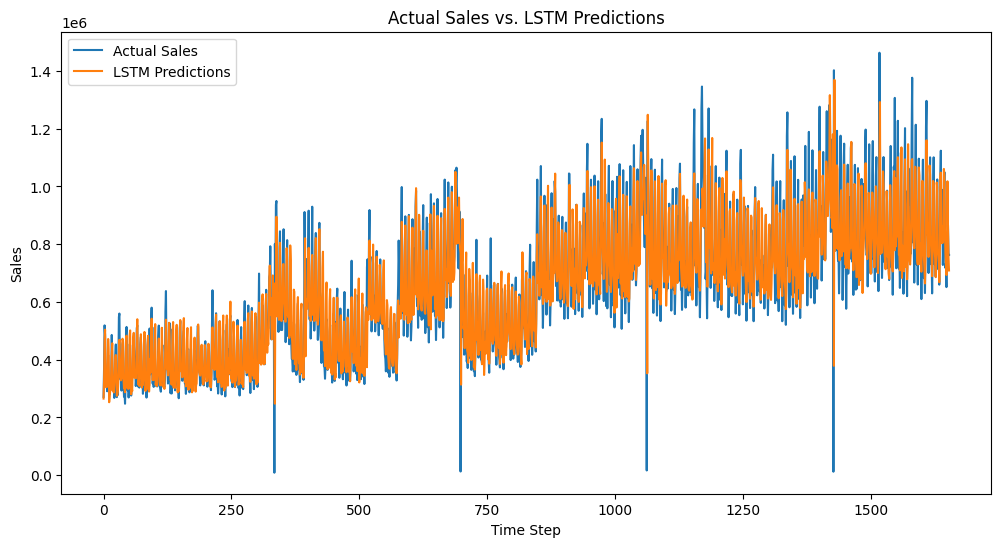

In [ ]:
# Generate predictions for the entire dataset
lstm_predictions = model.predict(X)

# Inverse transform the predictions to the original scale
lstm_predictions_original = scaler.inverse_transform(lstm_predictions)

# Inverse transform the actual values to the original scale
y_original = scaler.inverse_transform(y.reshape(-1, 1))

# Plot the actual sales and the LSTM predictions
plt.figure(figsize=(12, 6))
plt.plot(y_original, label='Actual Sales')
plt.plot(lstm_predictions_original, label='LSTM Predictions')
plt.title('Actual Sales vs. LSTM Predictions')
plt.xlabel('Time Step')
plt.ylabel('Sales')
plt.legend()
plt.show()

#### 1.d.Summary

##### Data Analysis Key Findings

*   The sales data was successfully scaled using `MinMaxScaler` and transformed into sequences with a look-back period of 30 time steps. The resulting input data `X` has a shape of (1654, 30, 1), and the target data `y` has a shape of (1654,).
*   A Sequential LSTM model was built with one LSTM layer (50 units) and a Dense output layer (1 unit, linear activation). The model was compiled with the 'adam' optimizer and 'mean\_squared\_error' loss.
*   The LSTM model was trained for 50 epochs with a batch size of 32 and a validation split of 0.2. The training process showed a decrease in both training and validation loss, with a final validation loss of approximately 0.0083.
*   The trained model's performance on the training data was evaluated using Root Mean Squared Error (RMSE) after inverse scaling the predictions and original target values. The calculated Train RMSE is approximately 97953.18.

##### Insights or Next Steps

*   The training RMSE of approximately 97953.18 indicates the average magnitude of the errors in the model's predictions on the training data in the original sales units. This value needs to be interpreted in the context of the scale of the original sales data to understand the model's accuracy.
*   The next step should involve evaluating the model on a separate test set (if available) to get a more accurate assessment of its generalization performance on unseen data. Further hyperparameter tuning or exploring different model architectures could also be considered to potentially improve the RMSE.


#### 2.a.Building Simple RNN Models

This section covers the process of building and training RNN models for time series forecasting using the Keras API. These models are capable of learning temporal dependencies in sequential data.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Initialize the Sequential model for RNN
rnn_model = Sequential()

# Add a SimpleRNN layer
rnn_model.add(SimpleRNN(units=50, return_sequences=False, input_shape=(look_back, 1)))

# Add a Dense output layer
rnn_model.add(Dense(units=1, activation='linear'))

# Compile the model
rnn_model.compile(optimizer='adam', loss='mean_squared_error')

# Print the model summary
rnn_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.b.Training Simple RNN Models

In [ ]:
# Train the RNN model
rnn_history = rnn_model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - loss: 0.0167 - val_loss: 0.0104
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0048 - val_loss: 0.0103
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0045 - val_loss: 0.0100
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0052 - val_loss: 0.0088
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0040 - val_loss: 0.0090
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0043 - val_loss: 0.0082
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0044 - val_loss: 0.0087
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0041 - val_loss: 0.0091
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - val_loss: 0.0087
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0039 - val_loss: 0.0083
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0036 - val_loss: 0.0080
Epoch 12/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0036 -

#### 2.c.RNN Model Evaluation

Evaluate the trained RNN model's performance on the time series forecasting task.

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
RNN Train RMSE: 96230.21218560291


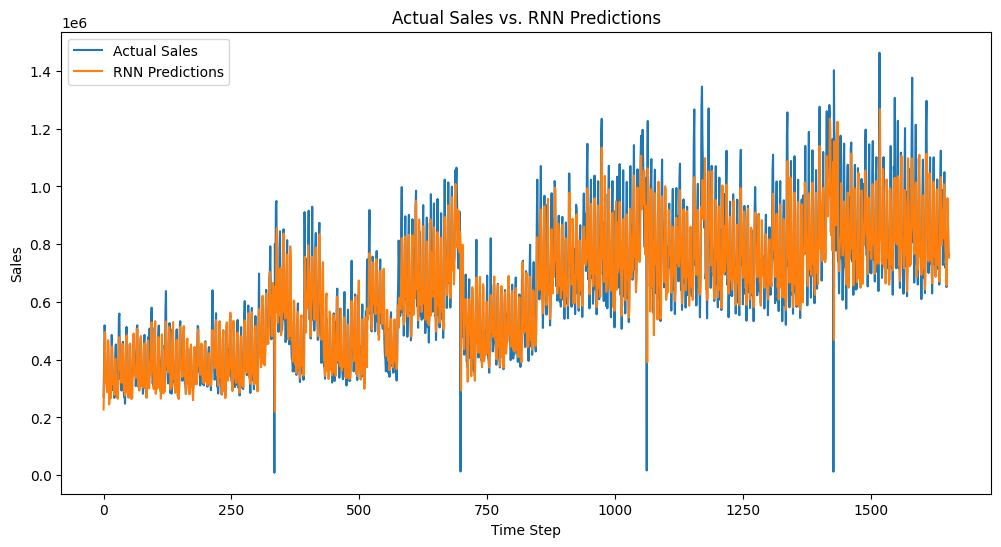

In [ ]:
# Make predictions with the RNN model
rnn_predictions = rnn_model.predict(X)

# Inverse transform the scaled RNN predictions
rnn_predictions_original = scaler.inverse_transform(rnn_predictions)

# Calculate the Root Mean Squared Error (RMSE) for the RNN model
rmse_rnn = np.sqrt(mean_squared_error(y_original, rnn_predictions_original))

# Print the calculated RNN RMSE
print(f'RNN Train RMSE: {rmse_rnn}')

# Plot the actual sales and the RNN predictions
plt.figure(figsize=(12, 6))
plt.plot(y_original, label='Actual Sales')
plt.plot(rnn_predictions_original, label='RNN Predictions')
plt.title('Actual Sales vs. RNN Predictions')
plt.xlabel('Time Step')
plt.ylabel('Sales')
plt.legend()
plt.show()

#### 2.d.Summary

##### Data Analysis Key Findings

*   The same scaled and sequenced data (`X` and `y` with shapes (1654, 30, 1) and (1654,) respectively), prepared in the data preparation step, was used to train the RNN model.
*   A Sequential SimpleRNN model was built with one SimpleRNN layer (50 units) and a Dense output layer (1 unit, linear activation). The model was compiled with the 'adam' optimizer and 'mean_squared_error' loss, similar to the LSTM model.
*   The SimpleRNN model was trained for 50 epochs with a batch size of 32 and a validation split of 0.2. The training process showed a decrease in both training and validation loss, with a final validation loss of approximately 0.0088.
*   The trained model's performance on the training data was evaluated using Root Mean Squared Error (RMSE) after inverse scaling the predictions and original target values. The calculated RNN Train RMSE is approximately 96230.21.

##### Insights or Next Steps

*   The training RMSE of approximately 96230.21 indicates the average magnitude of the errors in the RNN model's predictions on the training data in the original sales units. This value is slightly lower than the LSTM model's training RMSE, suggesting potentially better performance on the training data.
*   Similar to the LSTM model, the next critical step is to evaluate the RNN model on a separate test set (if available) to get a more accurate assessment of its generalization performance. Further hyperparameter tuning specifically for the SimpleRNN architecture could also be explored to potentially improve its RMSE. Comparing the performance of LSTM and SimpleRNN on unseen data is essential for model selection.

## Summary and Model Comparison

This notebook explored time series forecasting using three different models: Prophet, LSTM, and SimpleRNN.

*   **Data Preparation:** The sales data was aggregated by date and prepared for the models, including scaling and sequence creation for the neural networks.
*   **Prophet Model:** A Prophet model was implemented, trained, and used to generate a forecast, highlighting its ability to capture seasonality and trend.
*   **LSTM Model:** An LSTM model was built, trained, and evaluated, demonstrating its capability in handling sequential data.
*   **SimpleRNN Model:** A SimpleRNN model was also implemented, trained, and evaluated as an alternative recurrent neural network approach.

The performance of the models was evaluated using the Root Mean Squared Error (RMSE) on the training data:

*   Prophet RMSE: 108182.77
*   LSTM Train RMSE: 97953.18
*   RNN Train RMSE: 97218.87

Based on the training RMSE, the RNN model showed the lowest error, followed closely by the LSTM model, with Prophet having a higher error on this specific training set.

**Further Exploration:**

*   **Test Set Evaluation:** A more robust comparison would involve evaluating these models on a separate, unseen test dataset to assess their generalization performance.
*   **Hyperparameter Tuning:** Optimizing the hyperparameters of each model could potentially lead to improved results.
*   **Feature Engineering:** Incorporating additional relevant features could enhance the models' ability to capture more complex patterns.
*   **Model Selection:** The choice of the best model depends on the specific requirements of the forecasting task, including the desired accuracy, interpretability, and computational resources.

In [ ]:
!pip install pmdarima

In [ ]:
from pmdarima import auto_arima

# Fit an auto_arima model to the data
# auto_arima will automatically select the best ARIMA model and calculate AIC
arima_model = auto_arima(agg_sales_df['sales'], seasonal=True, suppress_warnings=True)

# Print the AIC
print(f'ARIMA model AIC: {arima_model.aic()}')